# FLI Simulation for mimicking the time-resolved image acquisition

Simulate a full 3-D fluorescence lifetime image data by combining a binary
intensity mask (for specific image structure) with a multi-region ("multi-ROI") label mask, so different regions of the image can assign independent simulator configurations for region specific lifetime variation. 
This example walks through:
- loading data 
- Setting the Imaging Instruments related parameters (laser repetition  rate, delay in acquisition, etc)
- Make an easy choice of tyoe of sample (mono-expontial, bi-expoential, or mixer of both decay model)
- configuring detector / noise settings (jitter, dark counts, shot noise, quantization),
- defining per-region simulator configs and assembling them with
  `FLIModelImageGenerator`,
- generating the full decay / fit / IRF cubes and per-pixel parameter maps,
  and
- visualizing the resulting lifetime, photon-count, and mono/bi-exponential
  maps, and probing a single pixel's decay trace.

In [1]:
## importing the modules required for this work
import matplotlib.pyplot as plt

from pyfli.analysis.utils import random_true_pixel
from pyfli.analytical_methods import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, DataViewer
from pyfli.io import DataOperations
from pyfli.simulator import FLIModelImageGenerator

In [9]:
IRF_PATH = "<select file/folder path>"

In [10]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()
print(f"IRF data shape is: {irf_data.shape}")

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()
print(f"the frequency use is: {freq[1]} MHz")

bmask_img = plt.imread("<select file/folder path>")
b_bool_mask = (bmask_img[..., 0] > 0) if bmask_img.ndim == 3 else (bmask_img > 0)

img_intensity = "<select file/folder path>"
img_mask = "<select file/folder path>"

INFO:pyfli:Initiating IRF load from: <select file/folder path>


IRF data shape is: (512, 512, 256)
the frequency use is: 80.0 MHz


In [11]:
# select the type of decay model to simulate
MODEL_TYPE = "mono-exponential"
if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0
else:
    mono_fraction = 0.4     # fraction of mono-exponential model in sampled data


# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter":           True,               # offset artifact (due to jitter)
    "dcr_on":           True,               # Dark Count Rate (thermal background)
    "poisson":          True,               # Shot noise — Large detector only
    "qe_on":            True,               # Quantum efficiency scaling
    "read_noise_on":    True,               # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type":      "PHOTON_COUNTER",   # "DECAY EQUATION" | "PHOTON_COUNTER"

    "dcr":              0.08,               # Mean dark counts per bin
    "laser_feq":        80,                 # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on":         True,               # Round photon counts to integers — Macro_sim only
    "clip_on":          True,               # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2":             (1, 1),             # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist":        "beta",             # if dist "beta" or "normal" (default)
    "efficiency":       (1, 1),             # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction":      (1, 1),             # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count":      (4, 4),             # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction":    mono_fraction,      # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles":         1_000_000,          # Accumulation cycles — for photon counter
}


def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


poisson_noise = True
jitter_on = True

ROI0 = {}  # no override — background region uses BASE_CONFIG as-is
ROI1 = get_config(
    poisson=poisson_noise,
    jitter=jitter_on,
    tau2_beta_range=(0.05, 0.6),
)
ROI2 = get_config(
    poisson=poisson_noise,
    jitter=jitter_on,
    tau2_beta_range=(0.05, 1),
)
ROI3 = get_config(
    poisson=poisson_noise,
    jitter=jitter_on,
    tau2_beta_range=(0.05, 1.5),
)

In [12]:
simulated_img = FLIModelImageGenerator(
    irf_data = irf_data,
    intensity_image_path = img_intensity,
    roi_mask_path = img_mask,
    roi_params = [ROI0, ROI1, ROI2, ROI3],
    method = "PHOTON_COUNTER",
    verbose = True,
    bool_mask = b_bool_mask,
)

gt_data = simulated_img.generate_image()

Generating PHOTON_COUNTER FLI Image [512x512x256]...


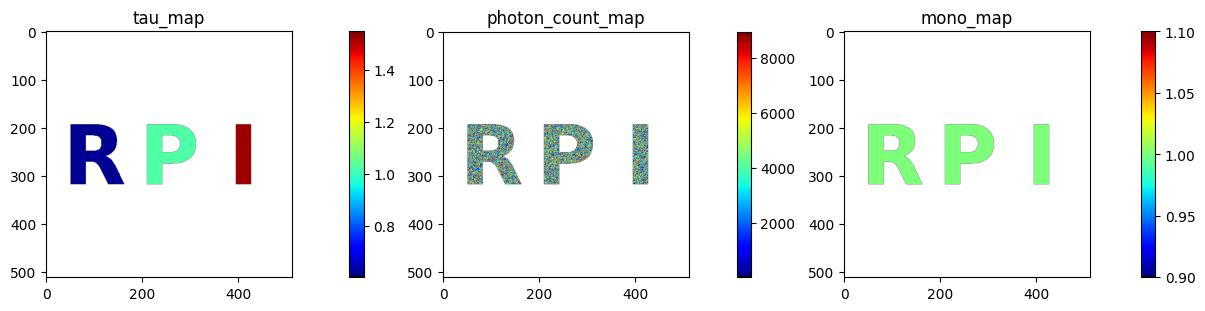

In [13]:
res = gt_data["results"]["maps"]
if MODEL_TYPE == "bi-exponential":
    data_list = [
        res["tau1_map"],
        res["tau2_map"],
        res["alpha1_map"],
        res["A1_map"],
        res["A2_map"],
        res["fret_efficiency_map"],
        res["tau_mean_map"],
        res["photon_count_map"],
        res["mono_map"],
    ]
    data_names = [
        "tau1_map",
        "tau2_map",
        "alpha1_map",
        "A1_map",
        "A2_map",
        "fret_efficiency_map",
        "tau_mean_map",
        "photon_count_map",
        "mono_map",
    ]
    rows = 3
    fig_size = (13, 9)
else:
    data_list = [res["tau_map"], res["photon_count_map"], res["mono_map"]]
    data_names = ["tau_map", "photon_count_map", "mono_map"]
    rows = 1
    fig_size = (12, 3)
jet_m = ColorProcessor().lowest_zero("jet")
cmaps = [jet_m] * len(data_list)
v_ranges = None
px = None

if px is None:
    cols = int(len(data_list) / rows)
else:
    cols = int(len(data_list) / rows) + 1


_ = DataViewer().display_data(
    data_list,
    structure=(rows, cols),
    coord=px,
    data_names=data_names,
    cmaps=cmaps,
    v_ranges=v_ranges,
    figsize=fig_size,
    normalize=False,
    yscale="linear",
)

the non-zero pixel selected for probing is (215, 305)


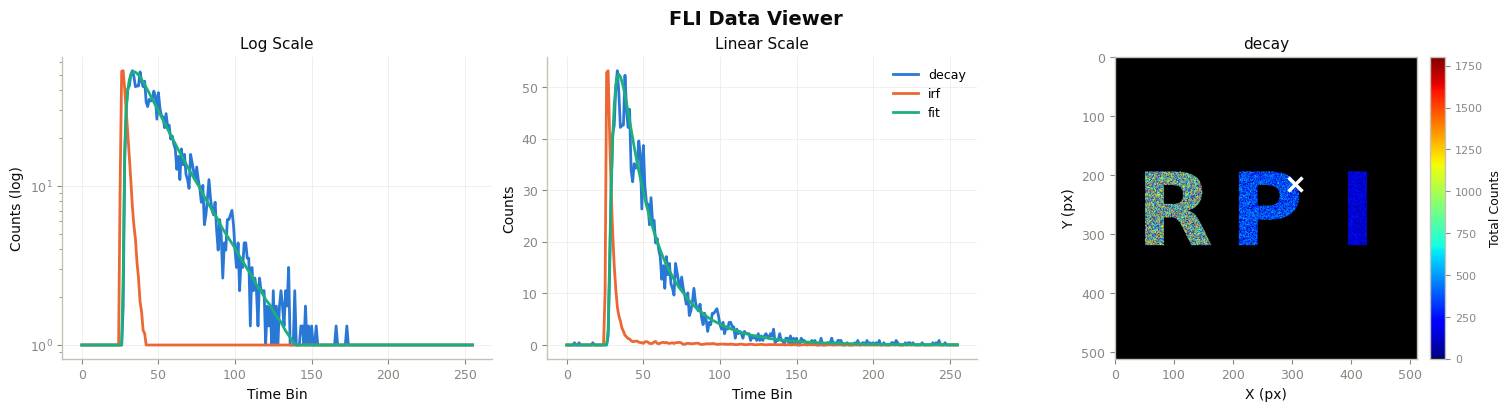

INFO:pyfli:
  Pixel (215, 305)
  ─────────────────────
  A         3805.3064
  α         —
  τ₁        1.0057
  τ₂        —
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   —
  h-shift   —
  ─────────────────────



In [14]:
sim_decay = gt_data["raw_data"]["decay"]
sim_irf = gt_data["raw_data"]["irf"]
x, y = random_true_pixel(b_bool_mask)
TRs = gt_data["results"]["TR_maps"]
maps = gt_data["results"]["maps"]
print(f"the non-zero pixel selected for probing is ({x}, {y})")
irf_norm = Normalization(sim_irf).norm_scale(sim_decay)
DataViewer().plot_fli_px(
    data_list=[sim_decay, irf_norm, TRs["fit_map"], TRs["residual_map"]],
    pixel=(x, y),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m,
)
_ = MessageDisplay().get_pixel_summary(data_maps=maps, px=(x, y))